"""

This script demonstrates training and inference for object detection using Ultralytics YOLOv8 and Ultralytics Yolov9 on a custom Roboflow dataset of Plant CSC rosette images.

Features:

Visualize Training Images

Train YOLOv8 segmentation model

Validate YOLOv8 segmentation model


Train YOLOv9 segmentation model

Validate YOLOv9 segmentation model

Run inference on test images with YOLOv8


"""

# Import Libraries

In [ ]:
# import libraries
import zipfile
import requests
import cv2
import matplotlib.pyplot as plt
import glob
import random
import os
import time
from pathlib import Path

In [ ]:
# connect colab workspace to drive if needed
from google.colab import drive
drive.mount('/content/drive')

#INCLUDE PATH TO ROOT OF DOWNLOADED GITHUB FOLDER
REPO_ROOT = Path('')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 118.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

# Verify and Visualize Dataset

# Install + Import Ultralytics YOLO for model training and validation

In [ ]:
# import YOLO
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# check file path and number of images for training, valid, and test data set
!ls -1 {REPO_ROOT}/Segmentation/LobeSegmentation_v3/train/images | wc -l
!ls -1 {REPO_ROOT}/Segmentation/LobeSegmentation_v3/test/images | wc -l
!ls -1 {REPO_ROOT}/Segmentation/LobeSegmentation_v3/valid/images | wc -l

68
16
16


In [ ]:
# function to plot the bounding boxes to their respective images
def plot_box(image, bboxes, labels):
    h, w = image.shape[:2]
    for box, label in zip(bboxes, labels):
        xs = box[::2]
        ys = box[1::2]

        xmin_norm = min(xs)
        ymin_norm = min(ys)
        xmax_norm = max(xs)
        ymax_norm = max(ys)

        xmin = int(xmin_norm * w)
        ymin = int(ymin_norm * h)
        xmax = int(xmax_norm * w)
        ymax = int(ymax_norm * h)

        thickness = max(2, int(w/275))
        cv2.rectangle(
            image,
            (xmin, ymin), (xmax, ymax),
            color=(0, 0, 255),
            thickness=thickness
        )
    return image

In [ ]:
# function to plot images with the bounding boxes
def plot(image_paths, label_paths, num_samples):
    all_images = glob.glob(os.path.join(image_paths, '*.[jJ][pP][gG]'))
    random.shuffle(all_images)

    plt.figure(figsize=(15, 12))

    for i in range(num_samples):
        if i >= len(all_images):
            break

        image_path = all_images[i]
        image = cv2.imread(image_path)
        if image is None:
            continue

        # Get corresponding label
        image_name = os.path.splitext(os.path.basename(image_path))[0]
        label_path = os.path.join(label_paths, f"{image_name}.txt")

        bboxes = []
        labels = []

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 11:
                        continue

                    label = parts[0]
                    coords = list(map(float, parts[1:]))
                    bboxes.append(coords)
                    labels.append(label)

        result_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if bboxes:
            result_image = plot_box(result_image, bboxes, labels)

        plt.subplot(2, 2, i+1)
        plt.imshow(result_image)
        plt.axis('off')
        plt.title(image_name)

    plt.tight_layout()
    plt.show()

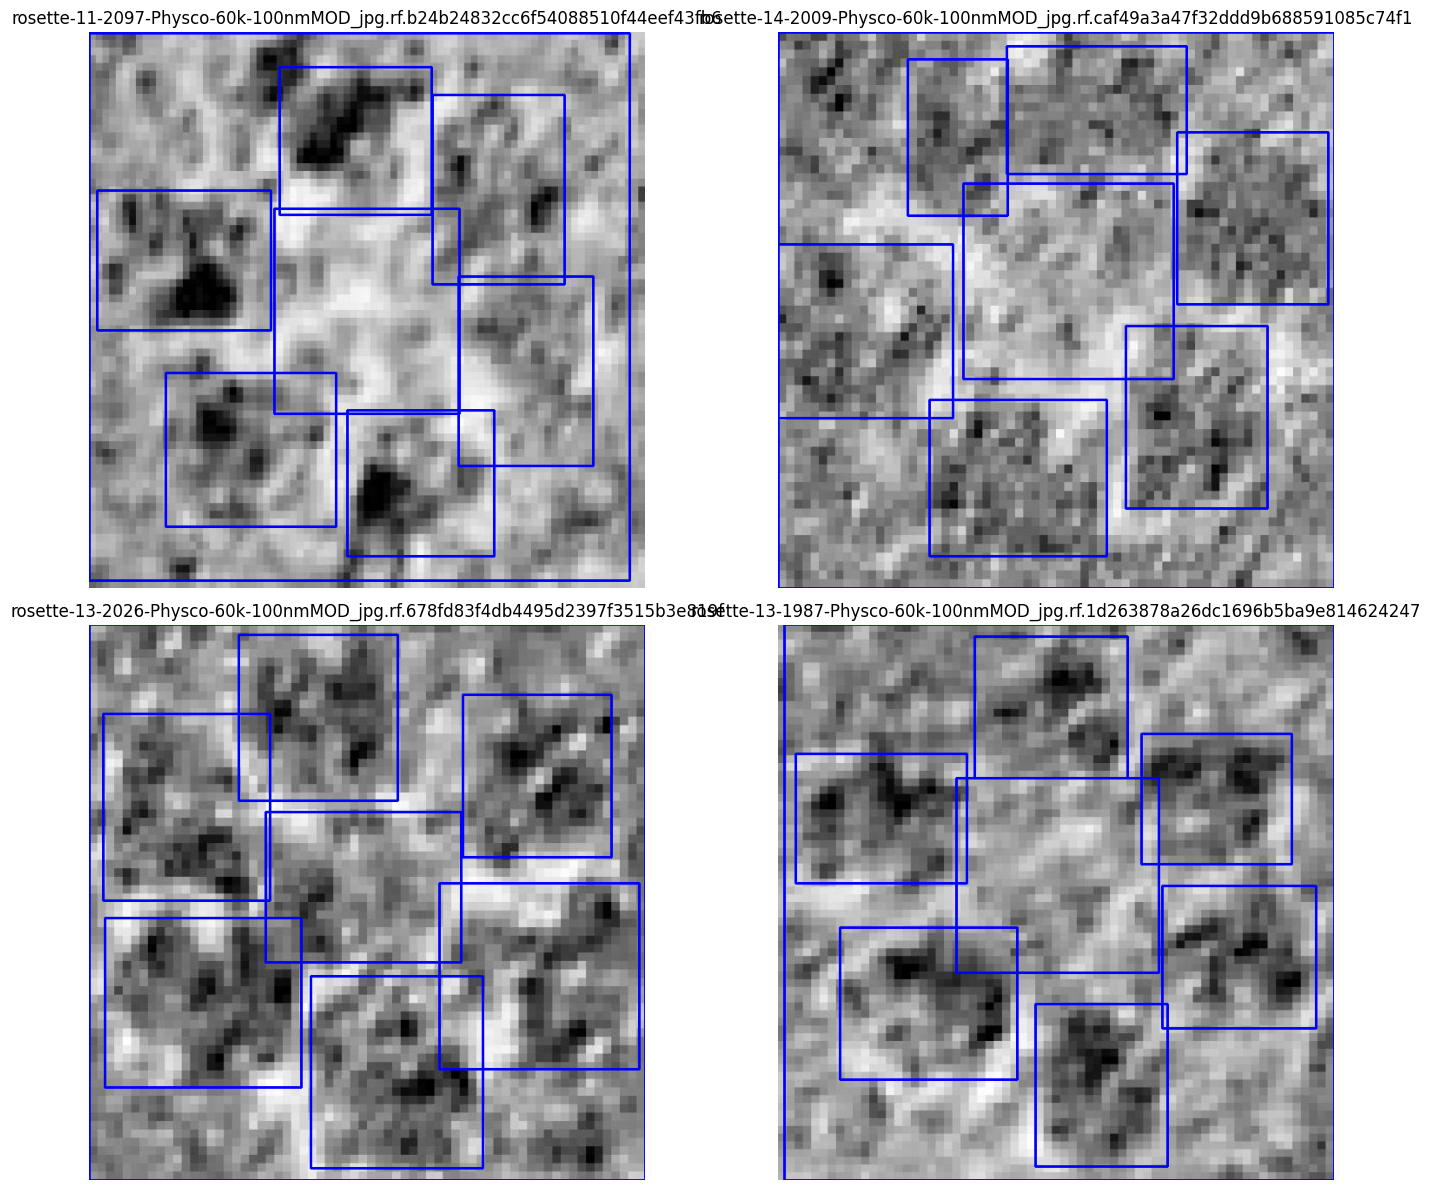

In [ ]:
plot(
    image_paths = '{REPO_ROOT}/Segmentation/LobeSegmentation_v3/train/images',
    label_paths= '{REPO_ROOT}/Segmentation/LobeSegmentation_v3/train/labels',
    num_samples = 4
)

# YOLOv8 Detection Model Train, Validate, Test

# Visualize Predictions on Test Images


"""

Features:
- Train YOLOv8 segmentation model
- Run inference on test images
- Validate performance on validation set

Requirements:
    pip install ultralytics roboflow opencv-python

"""



In [ ]:
%%writefile LobeSegmentation_v3.yaml
path: '{REPO_ROOT}/Segmentation/LobeSegmentation_v3'
train: 'train/images'
val: 'valid/images'

# class names
names:
  0: 'inner'
  1: 'lobe'
  2: 'outer'

Writing LobeSegmentation_v3.yaml


In [ ]:
# Setting up the hyperparameters
EPOCHS = 25
BATCH = 8
IMG_SIZE = 640

In [ ]:
# Finetune and train YOLOv8 model.
!yolo \
task = segment \
mode = train \
model = yolov8n-seg.pt \
imgsz = {IMG_SIZE} \
data = /content/LobeSegmentation_v3.yaml \
epochs = {EPOCHS} \
batch = {BATCH} \
name = yolov8n_v3_seg_run

Ultralytics 8.3.134 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/LobeSegmentation_v3.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_v3_seg_run2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True,

In [ ]:
# Evaluate model
!yolo \
task = segment \
mode = val \
model = {REPO_ROOT}/Segmentation/Yolov8_Segmentation/yolov8n_v3_seg_run/weights/best.pt \
name = yolov8n_seg_eval \
data = /content/LobeSegmentation_v3.yaml

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/ultralytics/cfg/__init__.py", line 952, in entrypoint
    model = YOLO(model, task=task)
            ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/ultralytics/models/yolo/model.py", line 53, in __init__
    super().__init__(model=model, task=task, verbose=verbose)
  File "/usr/local/lib/python3.11/dist-packages/ultralytics/engine/model.py", line 148, in __init__
    self._load(model, task=task)
  File "/usr/local/lib/python3.11/dist-packages/ultralytics/engine/model.py", line 292, in _load
    self.model, self.ckpt = attempt_load_one_weight(weights)
                            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/ultralytics/nn/tasks.py", line 1317, in attempt_load_one_weight
    ckpt, weight = torch_safe_load(weight)  # load ckpt
    

In [ ]:
# test model
start = time.time()
!yolo \
task = segment \
mode = predict \
model = {REPO_ROOT}/Segmentation/Yolov8_Segmentation/yolov8n_v3_seg_run/weights/best.pt \
source = {REPO_ROOT}/Segmentation/LobeSegmentation_v3/test/images \
imgsz = 640 \
name = yolov8n_v3_seg_pred \
conf = 0.5 \
show_labels = True
end = time.time()
print(f"Total execution time: {end - start:.2f} seconds")

Ultralytics 8.3.130 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n-seg summary (fused): 85 layers, 3,258,649 parameters, 0 gradients, 12.0 GFLOPs

image 1/16 /content/drive/MyDrive/ResearchDatasets/LobeSegmentation_v3/test/images/rosette-1-1988-Physco-60k-100nmMOD_jpg.rf.567e7bfce07291ad055515b90ac7aa2e.jpg: 640x640 1 inner, 6 lobes, 1 outer, 9.5ms
image 2/16 /content/drive/MyDrive/ResearchDatasets/LobeSegmentation_v3/test/images/rosette-1-2012-Physco-60k-100nmMOD_jpg.rf.8d802e3106529a7ddd0054d029b6beca.jpg: 640x640 6 lobes, 1 outer, 9.5ms
image 3/16 /content/drive/MyDrive/ResearchDatasets/LobeSegmentation_v3/test/images/rosette-1-2023-Physco-60k-100nmMOD_jpg.rf.bcaac5c3afc08acb6053be379cee3e25.jpg: 640x640 4 lobes, 1 outer, 18.2ms
image 4/16 /content/drive/MyDrive/ResearchDatasets/LobeSegmentation_v3/test/images/rosette-1-2035-Physco-60k-100nmMOD_jpg.rf.41a1b43cb23a6830aa95f16b8eff1844.jpg: 640x640 6 lobes, 1 outer, 10.2ms
image 5/16 /content/drive/MyDrive/Rese

# YOLOv9 Detection Model Train, Validate, Test

# YOLOv9 Segmentation Pipeline

## Features
- Load custom datasets in YOLO format
- Train a YOLOv9-seg model
- Visualize results using built-in plotting tools

## Requirements
```bash
pip install ultralytics opencv-python
```

---


In [ ]:
!pip install ultralytics

In [ ]:
# Load the YOLOv9 model for segmentation
# Build a YOLOv9c model from pretrained weight
model = YOLO("yolov9c-seg.pt")

# Display model information (optional)
model.info()

In [ ]:
# Finetune and train YOLOv9 model.
!yolo \
task = segment \
mode = train \
model = yolov9c-seg.pt \
imgsz = {IMG_SIZE} \
data = /content/LobeSegmentation_v3.yaml \
epochs = {EPOCHS} \
batch = {BATCH} \
name = yolov9n_v3_seg_run

In [ ]:
# Evaluate model
!yolo \
task = segment \
mode = val \
model = {REPO_ROOT}/Segmentation/Yolov9_Segmentation/yolov9n_v3_seg_run/weights/best.pt \
name = yolov9n_seg_eval \
data = /content/LobeSegmentation_v3.yaml

In [ ]:
# test model
start = time.time()
!yolo \
task = segment \
mode = predict \
model = {REPO_ROOT}/Segmentation/Yolov9_Segmentation/yolov9n_v3_seg_run/weights/best.pt \
source = {REPO_ROOT}/Segmentation/LobeSegmentation_v3/test/images \
imgsz = 640 \
name = yolov9n_v3_seg_pred \
conf = 0.5 \
show_labels = True
end = time.time()
print(f"Total execution time: {end - start:.2f} seconds")

# Visualize Predictions on Test Images

In [ ]:
# function for plotting and displyaing images and predicted annotations
def visualize(result_dir, num_samples=4) :
  plt.figure(figsize=(20,12))
  image_names = glob.glob(os.path.join(result_dir, '*.jpg'))
  random.shuffle(image_names)
  for i, image_name in enumerate(image_names):
    image = plt.imread(image_name)
    plt.subplot(2, 2, i+1)
    plt.imshow(image)
    plt.axis('off')
    if i == num_samples-1:
      break
  plt.tight_layout()
  plt.show()

In [ ]:
# visualize predicted images
visualize('{REPO_ROOT}/Segmentation/Yolov8_Segmentation/yolov8n_v3_seg_pred')